In [1]:
import os
import sys
import time
import dask
import zarr
import xesmf as xe
import numpy as np
import xarray as xr
from glob import glob

In [2]:
import pandas as pd
from tqdm import tqdm

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from scipy.stats import norm

### Get post-processed fcsts

In [5]:
VAR = VAR_CESM = 'TREFHTMN'
VAR_ERA5 = 'minimum_2m_temperature_since_previous_post_processing'
EPS = 1e-6        # floor for predicted variance
verif_years = np.arange(2010, 2020)

In [6]:
lat_ind = np.arange(192)

list_coef = []
list_missing = []
for lat_i in lat_ind:
    try:
        fn = f'/glade/derecho/scratch/ksha/EPRI_data/EMOS/{VAR_CESM}/emos_coef_lat_ind_{lat_i}.zarr'
        list_coef.append(xr.open_zarr(fn))
    except:
        list_missing.append(lat_ind)

In [7]:
ds_emos = xr.concat(list_coef, dim='lat')
ds_emos = ds_emos.load()
ds_emos = ds_emos.transpose('lead_time', 'lat', 'lon')

In [8]:
list_input = []
for year in verif_years:
    fn_CESM = f'/glade/derecho/scratch/ksha/EPRI_data/CESM2_SMYLE/SMYLE_{year}-11-01_daily_ensemble.zarr'
    ds_CESM = xr.open_zarr(fn_CESM)[[VAR_CESM,]].sel(time=slice(f"{year+1}-01-01", f"{year+10}-12-31"))
    ds_CESM = ds_CESM.rename({'time': 'lead_time'})
    ds_CESM['lead_time'] = np.arange(3650) # 10 non-leap year, 365 day on each 
    list_input.append(ds_CESM)

ds_input = xr.concat(list_input, dim='init_time')
ds_input = ds_input.assign_coords({'init_time': verif_years+1})

list_target = []
for year in range(2009, 2026):
    fn_ERA5 = f'/glade/derecho/scratch/ksha/EPRI_data/ERA5_grid/ERA5_{year}.zarr'
    ds_ERA5 = xr.open_zarr(fn_ERA5)[[VAR_ERA5,]].rename({VAR_ERA5: VAR_CESM})    
    list_target.append(ds_ERA5)

ds_target = xr.concat(list_target, dim='time')

In [9]:
# ════════════════════════════════════════════════════════════════════════
# Step 1: Noleap calendar → real-date index mapping
# ════════════════════════════════════════════════════════════════════════
 
def build_date_indices(init_years, n_lead, target_times):
    """
    Map every (init_time, lead_time) pair to an integer index into the
    target (ERA5) time axis.  Returns -1 where no matching date exists.
    
    The CESM2 noleap calendar has exactly 365 days per year (no Feb 29).
    For each model day we find the corresponding real-calendar date,
    then look it up in the ERA5 time coordinate.
    """
    time_to_idx = {pd.Timestamp(t): i for i, t in enumerate(target_times)}
    indices = np.full((len(init_years), n_lead), -1, dtype=np.int32)
 
    for i, year in enumerate(init_years):
        year = int(year)
        # Build the 3650-day noleap calendar for this initialisation
        noleap_dates = []
        for y in range(year, year + 10):
            days = pd.date_range(f'{y}-01-01', f'{y}-12-31', freq='D')
            days = days[~((days.month == 2) & (days.day == 29))]  # drop leap day
            noleap_dates.extend(days.tolist())
 
        for L in range(min(n_lead, len(noleap_dates))):
            d = noleap_dates[L]
            if d in time_to_idx:
                indices[i, L] = time_to_idx[d]
 
    return indices
 
 
print("Building noleap → real-calendar date mapping …")
init_years = ds_input.init_time.values           # [1959, 1960, …, 2010]
n_init     = len(init_years)
n_lead     = len(ds_input.lead_time)              # 3650
n_lat      = len(ds_input.lat)
n_lon      = len(ds_input.lon)
 
target_times_pd = pd.DatetimeIndex(ds_target.time.values)
date_idx = build_date_indices(init_years, n_lead, target_times_pd)
# date_idx shape: (n_init, n_lead) — value = position in target time axis
 
# Quick sanity check
n_valid_total = (date_idx >= 0).sum()
print(f"  Matched {n_valid_total} of {n_init * n_lead} (init, lead) pairs to ERA5 dates.\n")

Building noleap → real-calendar date mapping …
  Matched 32850 of 36500 (init, lead) pairs to ERA5 dates.



In [10]:
# ════════════════════════════════════════════════════════════════════════
# Step 5: Apply EMOS to produce calibrated forecasts
# ════════════════════════════════════════════════════════════════════════
 
def apply_emos(ds_input, ds_emos, var=VAR_CESM):
    """
    Apply fitted EMOS to ensemble forecasts.
    
    Returns an xr.Dataset with:
        emos_mu    : calibrated predictive mean   (init_time, lead_time, lat, lon)
        emos_sigma : calibrated predictive std     (init_time, lead_time, lat, lon)
    """
    ens_mean = ds_input[var].mean(dim='member')
    ens_var  = ds_input[var].var(dim='member', ddof=1)
 
    a = ds_emos['a']  # (lead_time, lat, lon)
    b = ds_emos['b']
    c = ds_emos['c']
    d = ds_emos['d']
 
    mu    = a + b * ens_mean                         # broadcast over init_time
    sigma = np.sqrt(np.maximum(c + d * ens_var, EPS))
 
    return xr.Dataset({
        'emos_mu':    mu,
        'emos_sigma': sigma,
    })
    
print("Applying EMOS to the training forecasts (for verification) …")
ds_calib = apply_emos(ds_input, ds_emos, var=VAR)
print(ds_calib)
print()

Applying EMOS to the training forecasts (for verification) …
<xarray.Dataset> Size: 16GB
Dimensions:     (lat: 192, lead_time: 3650, lon: 288, init_time: 10)
Coordinates:
  * lat         (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lead_time   (lead_time) int64 29kB 0 1 2 3 4 5 ... 3645 3646 3647 3648 3649
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * init_time   (init_time) int64 80B 2011 2012 2013 2014 ... 2018 2019 2020
Data variables:
    emos_mu     (lead_time, lat, lon, init_time) float32 8GB dask.array<chunksize=(5, 192, 288, 1), meta=np.ndarray>
    emos_sigma  (lead_time, lat, lon, init_time) float32 8GB dask.array<chunksize=(5, 192, 288, 1), meta=np.ndarray>



In [11]:
ds_calib = ds_calib.transpose('init_time', 'lead_time', 'lat', 'lon')
ds_calib = ds_calib.load()
# mu = ds_calib['emos_mu'].isel(init_time=0, lead_time=999).values
# sigma = ds_calib['emos_sigma'].isel(init_time=0, lead_time=999).values

In [12]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/PP_calib/TMIN_EMOS_calib.zarr'
ds_calib.to_zarr(fn, mode='w')

In [14]:
ds_calib

<xarray.Dataset> Size: 16GB
Dimensions:     (lat: 192, lead_time: 3650, lon: 288, init_time: 10)
Coordinates:
  * lat         (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lead_time   (lead_time) int64 29kB 0 1 2 3 4 5 ... 3645 3646 3647 3648 3649
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * init_time   (init_time) int64 80B 2011 2012 2013 2014 ... 2018 2019 2020
Data variables:
    emos_mu     (init_time, lead_time, lat, lon) float32 8GB 245.5 ... 249.8
    emos_sigma  (init_time, lead_time, lat, lon) float32 8GB 1.868 ... 6.096

### CRPS verif

In [12]:
# ════════════════════════════════════════════════════════════════════════
# Step 6 (optional): Quick verification — CRPS comparison
# ════════════════════════════════════════════════════════════════════════
 
def crps_gaussian(mu, sigma, obs):
    """Closed-form CRPS for N(mu, sigma²) vs scalar obs (vectorised)."""
    z = (obs - mu) / sigma
    return sigma * (z * (2.0 * norm.cdf(z) - 1.0) + 2.0 * norm.pdf(z) - 1.0 / np.sqrt(np.pi))
 

def crps_verif(ds_calib, ds_input, ds_target, date_idx, var=VAR_CESM, init_idx=None):
    """
    Vectorized CRPS verification for one or more initializations.

    Parameters
    ----------
    init_idx : int, list/array of ints, or None
        Which initialization(s) to evaluate.
        None  → all initializations in ds_input.
        int   → single initialization; returns 3D arrays.
        list  → multiple initializations; returns 4D arrays.

    Returns
    -------
    raw_crps  : np.ndarray
        (lead_time, lat, lon) if single init,
        (n_init, lead_time, lat, lon) if multiple.
    emos_crps : np.ndarray
        Same shape as raw_crps.
        NaN where the corresponding ERA5 date is missing.
    """
    n_lead = ds_input.sizes['lead_time']
    n_lat  = ds_input.sizes['lat']
    n_lon  = ds_input.sizes['lon']

    target_vals = ds_target[var].values.astype(np.float32)  # (time, lat, lon)

    # ── Normalize init_idx ──
    squeeze = False
    if init_idx is None:
        init_idx = np.arange(ds_input.sizes['init_time'])
    elif isinstance(init_idx, (int, np.integer)):
        init_idx = [init_idx]
        squeeze = True
    init_idx = np.asarray(init_idx)
    n_sel = len(init_idx)

    # ── Allocate output ──
    raw_crps  = np.full((n_sel, n_lead, n_lat, n_lon), np.nan, dtype=np.float32)
    emos_crps = np.full_like(raw_crps, np.nan)

    for j, ii in enumerate(init_idx):

        # ── Obs: (lead_time, lat, lon) ──
        obs = np.full((n_lead, n_lat, n_lon), np.nan, dtype=np.float32)
        valid_leads = date_idx[ii] >= 0
        lead_idx    = np.where(valid_leads)[0]
        time_idx    = date_idx[ii, lead_idx]
        obs[lead_idx, :, :] = target_vals[time_idx, :, :]

        # ── Ensemble stats: (lead_time, lat, lon) ──
        ens_slice = ds_input[var].isel(init_time=ii)
        raw_mu  = ens_slice.mean('member').values.astype(np.float32)
        raw_std = ens_slice.std('member', ddof=1).values.astype(np.float32)
        raw_std = np.maximum(raw_std, EPS)

        # ── EMOS calibrated: (lead_time, lat, lon) ──
        emos_mu  = ds_calib['emos_mu'].isel(init_time=ii).values.astype(np.float32)
        emos_sig = ds_calib['emos_sigma'].isel(init_time=ii).values.astype(np.float32)
        emos_sig = np.maximum(emos_sig, EPS)

        # ── Vectorized CRPS ──
        raw_crps[j]  = crps_gaussian(raw_mu, raw_std, obs)
        emos_crps[j] = crps_gaussian(emos_mu, emos_sig, obs)

        # Mask missing obs
        invalid = np.isnan(obs)
        raw_crps[j][invalid]  = np.nan
        emos_crps[j][invalid] = np.nan

    # ── Summary ──
    raw_mean  = np.nanmean(raw_crps)
    emos_mean = np.nanmean(emos_crps)
    n_valid   = np.sum(~np.isnan(raw_crps))
    print(f"CRPS verification ({n_sel} init(s), {n_valid:,} valid cells):")
    print(f"  Raw ensemble : {raw_mean:.4f}")
    print(f"  EMOS         : {emos_mean:.4f}")
    print(f"  Improvement  : {100 * (raw_mean - emos_mean) / raw_mean:.1f}%")

    # ── Squeeze back to 3D for single init ──
    if squeeze:
        raw_crps  = raw_crps[0]
        emos_crps = emos_crps[0]

    return raw_crps, emos_crps

In [13]:
raw_crps, emos_crps = crps_verif(ds_calib, ds_input, ds_target, date_idx, var=VAR_CESM)

CRPS verification (10 init(s), 1,816,473,600 valid cells):
  Raw ensemble : 2.1551
  EMOS         : 1.4681
  Improvement  : 31.9%


In [14]:
raw_crps.shape

(10, 3650, 192, 288)

In [15]:
emos_crps.shape

(10, 3650, 192, 288)

In [16]:
ds_verif = xr.Dataset(
    {
        "CRPS_CESM": (["init_time", "lead_time", "lat", "lon"], raw_crps),
        "CRPS_EMOS": (["init_time", "lead_time", "lat", "lon"], emos_crps),
    },
    coords={
        "init_time": verif_years,
        "lead_time": np.arange(3650),
        "lat": ds_input.lat.values,
        "lon": ds_input.lon.values,
    },
)

In [17]:
fn_save = f'/glade/derecho/scratch/ksha/EPRI_data/PP_verif/TMIN_EMOS_{verif_years[0]}_{verif_years[-1]}.zarr'
ds_verif.to_zarr(fn_save, mode='w')

In [18]:
ds_verif

<xarray.Dataset> Size: 16GB
Dimensions:    (init_time: 10, lead_time: 3650, lat: 192, lon: 288)
Coordinates:
  * init_time  (init_time) int64 80B 2010 2011 2012 2013 ... 2016 2017 2018 2019
  * lead_time  (lead_time) int64 29kB 0 1 2 3 4 5 ... 3645 3646 3647 3648 3649
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    CRPS_CESM  (init_time, lead_time, lat, lon) float32 8GB 17.79 17.79 ... nan
    CRPS_EMOS  (init_time, lead_time, lat, lon) float32 8GB 1.31 1.309 ... nan

### Check

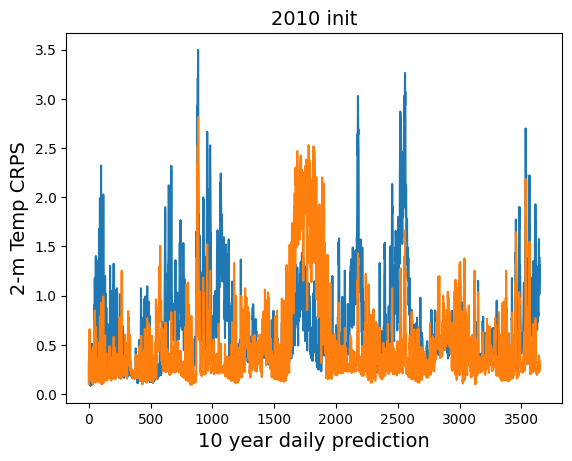

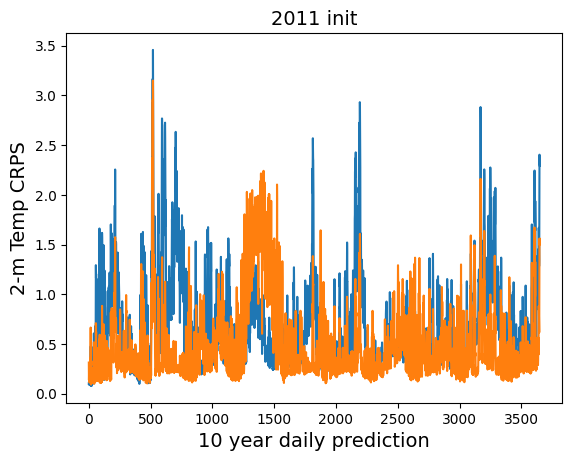

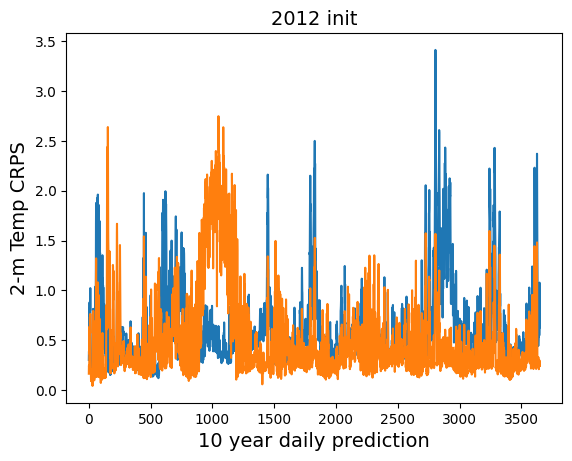

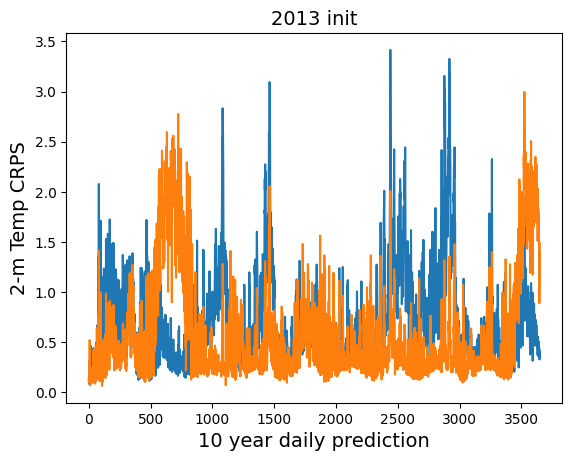

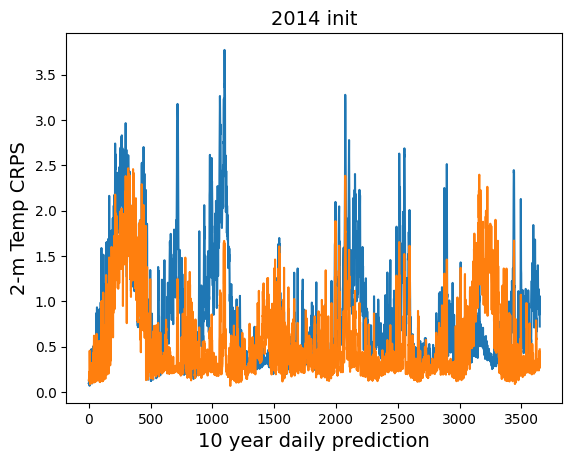

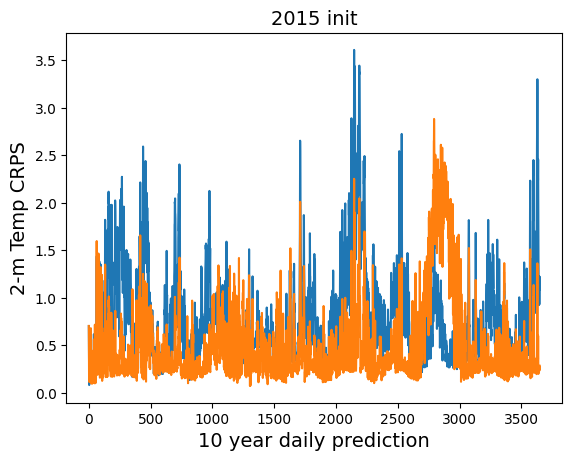

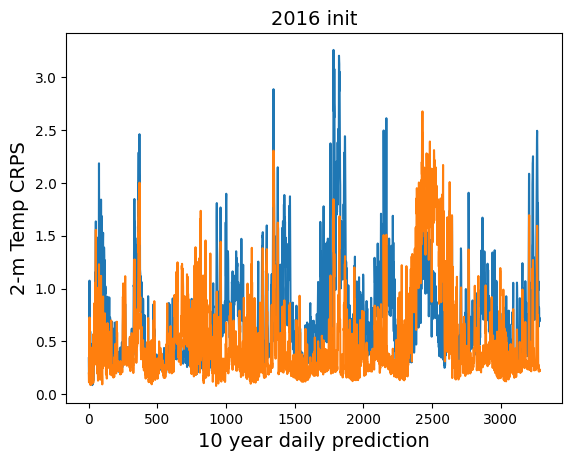

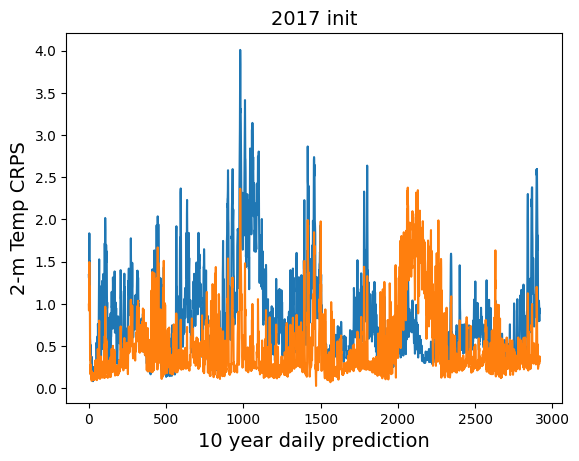

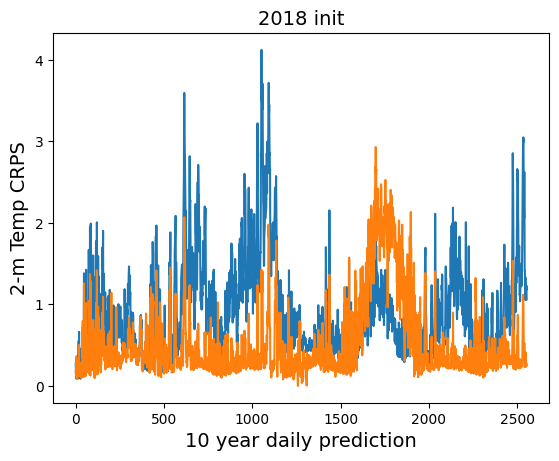

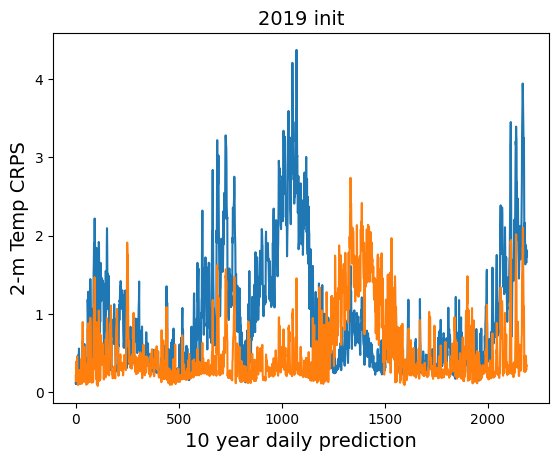

In [19]:
for i in range(10):
    plt.figure()
    plt.plot(raw_crps[i, :, 99, 199])
    plt.plot(emos_crps[i, :, 99, 199])
    plt.xlabel('10 year daily prediction', fontsize=14)
    plt.ylabel('2-m Temp CRPS', fontsize=14)
    plt.title(f'{verif_years[i]} init', fontsize=14)